In [1]:
# Feature Engineering for INR Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Libraries loaded!")
print(f"📅 Today: {datetime.now().strftime('%Y-%m-%d')}")

✅ Libraries loaded!
📅 Today: 2026-02-23


In [17]:
# Load all datasets
print("Loading datasets...\n")

df_currency = pd.read_csv('E:/Projects/INR_Currency_Project/data/raw/currency_data.csv', 
                          index_col=0, parse_dates=True)
df_economic = pd.read_csv('E:/Projects/INR_Currency_Project/data/raw/economic_indicators.csv', 
                          index_col=0, parse_dates=True)
df_commodity = pd.read_csv('E:/Projects/INR_Currency_Project/data/raw/commodity_prices.csv', 
                           index_col=0, parse_dates=True)
df_events = pd.read_csv('E:/Projects/INR_Currency_Project/data/raw/event_indicators.csv', 
                        index_col=0, parse_dates=True, dayfirst=True)

print("✓ All data loaded")

# Merge everything into one dataframe
df = df_currency.copy()
df = df.join(df_economic, how='left')
df = df.join(df_commodity, how='left')
df = df.join(df_events, how='left')

print(f"\nCombined Dataset:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {df.shape[1]}")
print(f"  Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"\nFirst 5 rows:")
df.head()

Loading datasets...

✓ All data loaded

Combined Dataset:
  Shape: (4191, 34)
  Columns: 34
  Date range: 2010-01-01 to 2026-02-05

First 5 rows:


,INR_USD,EUR_USD,GBP_USD,JPY_USD,CNY_USD,AUD_USD,VIX,SP500,DXY,US_10Y_Treasury,...,EM_Currency_Crisis_2018,COVID_19_Pandemic,Oil_War_2020,Ukraine_Russia_War,Global_Inflation_Crisis,Fed_Tightening_Cycle,Trump_Tariffs_2025,India_Pakistan_Tensions,Any_Crisis,Crisis_Count
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-01 00:00:00,46.610001,1.438994,1.613294,92.919998,NaN,0.898473,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2010-01-04 00:00:00,46.287998,1.442398,1.611370,92.495003,6.8169,0.912492,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2010-01-05 00:00:00,46.119999,1.436596,1.599079,91.584999,6.8170,0.911826,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2010-01-06 00:00:00,45.720001,1.440403,1.602384,92.356003,6.8183,0.920471,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2010-01-07 00:00:00,45.688000,1.431803,1.593397,93.389999,6.8178,0.917768,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


TARGET VARIABLES CREATED

 INR Daily Returns:
  Mean: 0.0169%
  Std Dev: 0.4748%
  Min: -5.9151%
  Max: 6.2870%

 Binary Target Distribution:
INR_Weakens_Tomorrow
0    2102
1    2089
Name: count, dtype: int64
  Class balance: 49.8% positive

 Direction Target Distribution:
INR_Direction
Stable         3400
Strong Up       436
Strong Down     354
Name: count, dtype: int64


C:\Users\Dhruv Chaudhary\AppData\Local\Temp\ipykernel_40716\406741558.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['INR_Return'] = df['INR_USD'].pct_change() * 100


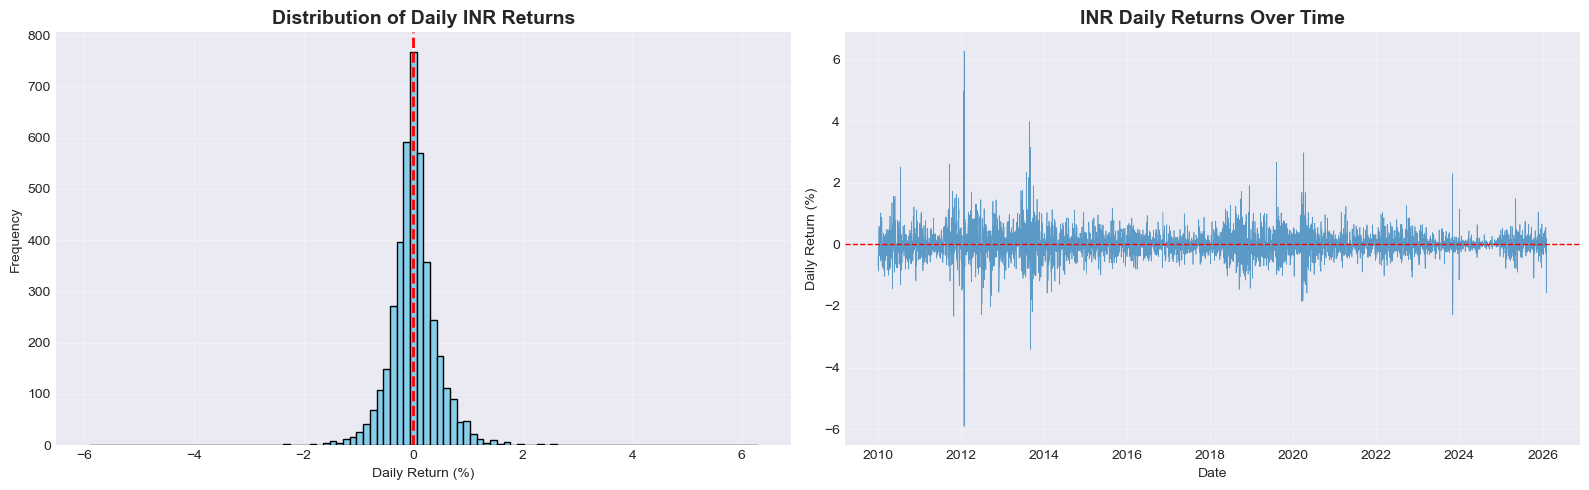

In [18]:
# Create target variable: Next day's INR/USD change

# Calculate daily returns (percentage change)
df['INR_Return'] = df['INR_USD'].pct_change() * 100

# Create binary target: Will INR weaken tomorrow? (1=Yes, 0=No)
df['INR_Weakens_Tomorrow'] = (df['INR_Return'].shift(-1) > 0).astype(int)

# Create categorical target for multi-class
df['INR_Direction'] = pd.cut(df['INR_Return'].shift(-1), 
                              bins=[-np.inf, -0.5, 0.5, np.inf],
                              labels=['Strong Down', 'Stable', 'Strong Up'])

print("="*70)
print("TARGET VARIABLES CREATED")
print("="*70)

print(f"\n INR Daily Returns:")
print(f"  Mean: {df['INR_Return'].mean():.4f}%")
print(f"  Std Dev: {df['INR_Return'].std():.4f}%")
print(f"  Min: {df['INR_Return'].min():.4f}%")
print(f"  Max: {df['INR_Return'].max():.4f}%")

print(f"\n Binary Target Distribution:")
print(df['INR_Weakens_Tomorrow'].value_counts())
print(f"  Class balance: {df['INR_Weakens_Tomorrow'].mean()*100:.1f}% positive")

print(f"\n Direction Target Distribution:")
print(df['INR_Direction'].value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Returns distribution
axes[0].hist(df['INR_Return'].dropna(), bins=100, color='skyblue', edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Distribution of Daily INR Returns', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

# Returns over time
axes[1].plot(df.index, df['INR_Return'], linewidth=0.5, alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('INR Daily Returns Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Daily Return (%)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# Create lagged features - past values to predict future

print("Creating lagged features...\n")

# INR lags (yesterday, 2 days ago, 3 days ago, etc.)
for lag in [1, 2, 3, 5, 7, 14, 30]:
    df[f'INR_USD_Lag{lag}'] = df['INR_USD'].shift(lag)
    df[f'INR_Return_Lag{lag}'] = df['INR_Return'].shift(lag)
    print(f"✓ Created lag {lag} features")

# Other currency lags
for currency in ['EUR_USD', 'GBP_USD', 'JPY_USD']:
    for lag in [1, 3, 7]:
        df[f'{currency}_Lag{lag}'] = df[currency].shift(lag)

print(f"\n✅ Created {len([col for col in df.columns if 'Lag' in col])} lagged features")

# Example: Show how lags work
print("\nExample - INR_USD with lags:")
print(df[['INR_USD', 'INR_USD_Lag1', 'INR_USD_Lag3', 'INR_USD_Lag7']].head(10))

Creating lagged features...

✓ Created lag 1 features
✓ Created lag 2 features
✓ Created lag 3 features
✓ Created lag 5 features
✓ Created lag 7 features
✓ Created lag 14 features
✓ Created lag 30 features

✅ Created 23 lagged features

Example - INR_USD with lags:
                       INR_USD  INR_USD_Lag1  INR_USD_Lag3  INR_USD_Lag7
Date                                                                    
2010-01-01 00:00:00  46.610001           NaN           NaN           NaN
2010-01-04 00:00:00  46.287998     46.610001           NaN           NaN
2010-01-05 00:00:00  46.119999     46.287998           NaN           NaN
2010-01-06 00:00:00  45.720001     46.119999     46.610001           NaN
2010-01-07 00:00:00  45.688000     45.720001     46.287998           NaN
2010-01-08 00:00:00  45.518002     45.688000     46.119999           NaN
2010-01-11 00:00:00  45.358002     45.518002     45.720001           NaN
2010-01-12 00:00:00  45.618000     45.358002     45.688000     46.610001
2010

Creating moving average features...

✓ Created MA5 features
✓ Created MA10 features
✓ Created MA20 features
✓ Created MA50 features
✓ Created MA100 features
✓ Created MA200 features

✅ Created 18 moving average features


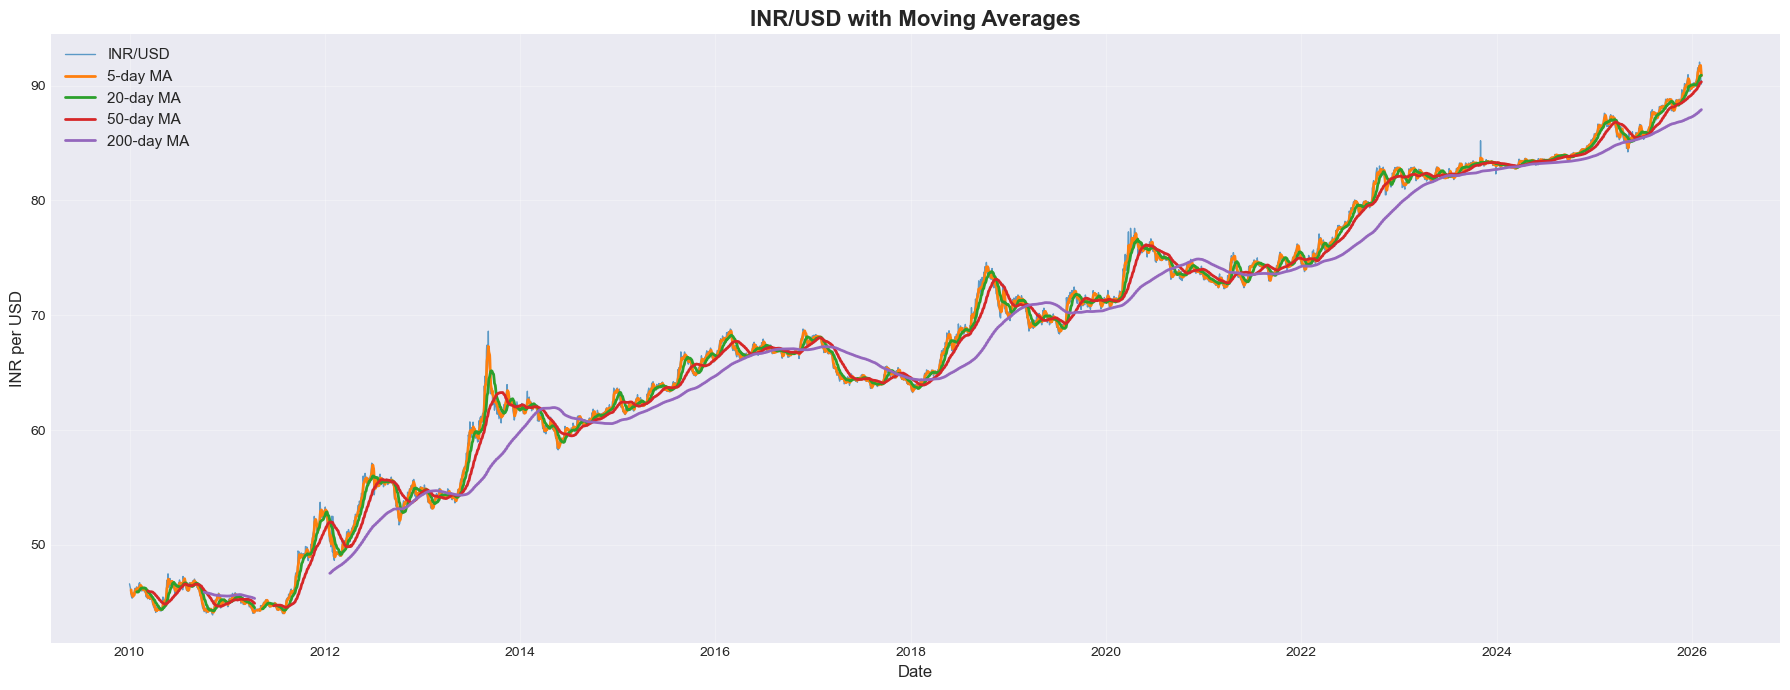


 Moving Average Signals:
  Current INR: ₹90.12
  5-day MA: ₹90.85
  20-day MA: ₹90.90
  50-day MA: ₹90.32


In [19]:
# Calculate moving averages to capture trends

print("Creating moving average features...\n")

windows = [5, 10, 20, 50, 100, 200]

for window in windows:
    # Simple moving average
    df[f'INR_MA{window}'] = df['INR_USD'].rolling(window=window).mean()
    
    # Distance from moving average (signal)
    df[f'INR_Distance_MA{window}'] = df['INR_USD'] - df[f'INR_MA{window}']
    
    # Moving average of other indicators
    df[f'VIX_MA{window}'] = df['VIX'].rolling(window=window).mean()
    
    print(f"✓ Created MA{window} features")

print(f"\n✅ Created {len([col for col in df.columns if 'MA' in col])} moving average features")

# Visualize moving averages
plt.figure(figsize=(18, 7))

plt.plot(df.index, df['INR_USD'], label='INR/USD', linewidth=1, alpha=0.7)
plt.plot(df.index, df['INR_MA5'], label='5-day MA', linewidth=2)
plt.plot(df.index, df['INR_MA20'], label='20-day MA', linewidth=2)
plt.plot(df.index, df['INR_MA50'], label='50-day MA', linewidth=2)
plt.plot(df.index, df['INR_MA200'], label='200-day MA', linewidth=2)

plt.title('INR/USD with Moving Averages', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('INR per USD', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Moving Average Signals:")
print(f"  Current INR: ₹{df['INR_USD'].iloc[-1]:.2f}")
print(f"  5-day MA: ₹{df['INR_MA5'].iloc[-1]:.2f}")
print(f"  20-day MA: ₹{df['INR_MA20'].iloc[-1]:.2f}")
print(f"  50-day MA: ₹{df['INR_MA50'].iloc[-1]:.2f}")

Creating volatility features...

✓ Created volatility features for 5-day window
✓ Created volatility features for 10-day window
✓ Created volatility features for 20-day window
✓ Created volatility features for 30-day window

✅ Created 8 volatility features


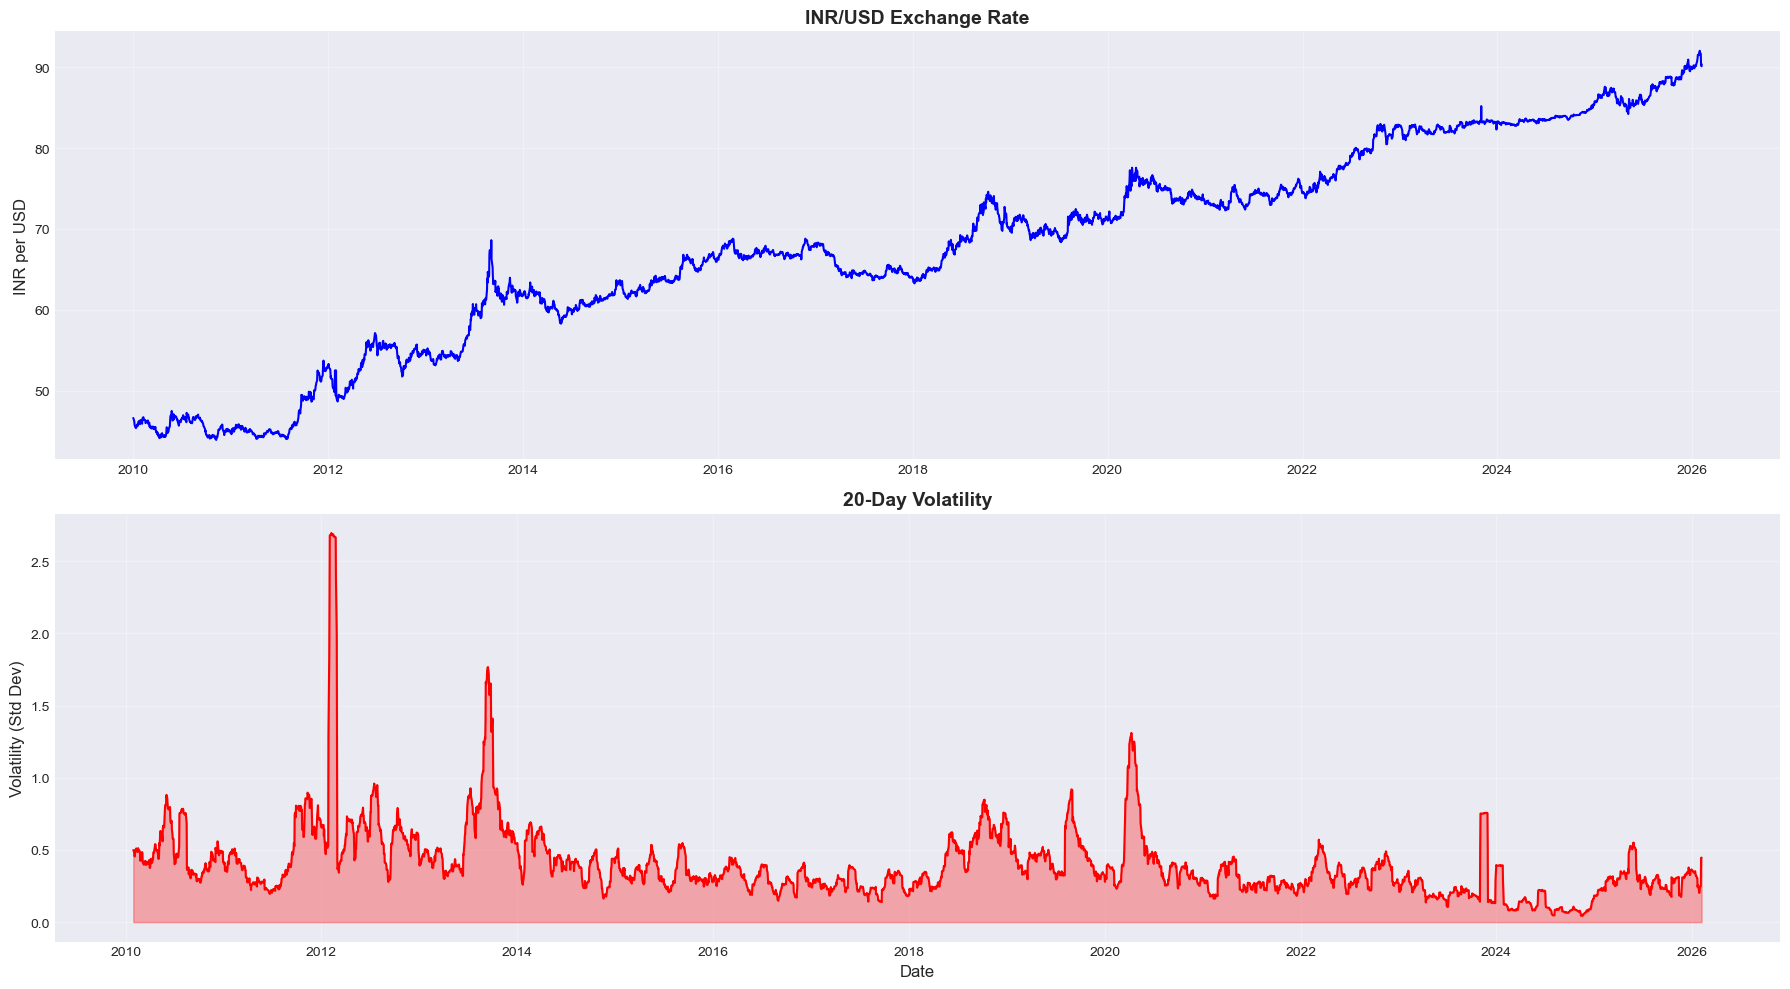


 Current Volatility:
  5-day: 0.6773%
  20-day: 0.4465%


In [20]:
# Create volatility features (measure of uncertainty)

print("Creating volatility features...\n")

windows = [5, 10, 20, 30]

for window in windows:
    # Standard deviation (volatility)
    df[f'INR_Volatility{window}'] = df['INR_Return'].rolling(window=window).std()
    
    # Rolling min/max
    df[f'INR_RollingMax{window}'] = df['INR_USD'].rolling(window=window).max()
    df[f'INR_RollingMin{window}'] = df['INR_USD'].rolling(window=window).min()
    
    # Range
    df[f'INR_Range{window}'] = df[f'INR_RollingMax{window}'] - df[f'INR_RollingMin{window}']
    
    print(f"✓ Created volatility features for {window}-day window")

print(f"\n✅ Created {len([col for col in df.columns if 'Volatility' in col or 'Range' in col])} volatility features")

# Visualize volatility
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# INR price
axes[0].plot(df.index, df['INR_USD'], linewidth=1.5, color='blue')
axes[0].set_title('INR/USD Exchange Rate', fontsize=14, fontweight='bold')
axes[0].set_ylabel('INR per USD', fontsize=12)
axes[0].grid(alpha=0.3)

# Volatility
axes[1].plot(df.index, df['INR_Volatility20'], linewidth=1.5, color='red')
axes[1].fill_between(df.index, df['INR_Volatility20'], alpha=0.3, color='red')
axes[1].set_title('20-Day Volatility', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Volatility (Std Dev)', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Current Volatility:")
print(f"  5-day: {df['INR_Volatility5'].iloc[-1]:.4f}%")
print(f"  20-day: {df['INR_Volatility20'].iloc[-1]:.4f}%")

Creating time-based features...

✅ Created time-based features

 Average INR Return by Day of Week:
  Monday: -0.0556%
  Tuesday: +0.1071%
  Wednesday: +0.0201%
  Thursday: -0.0102%
  Friday: +0.0229%


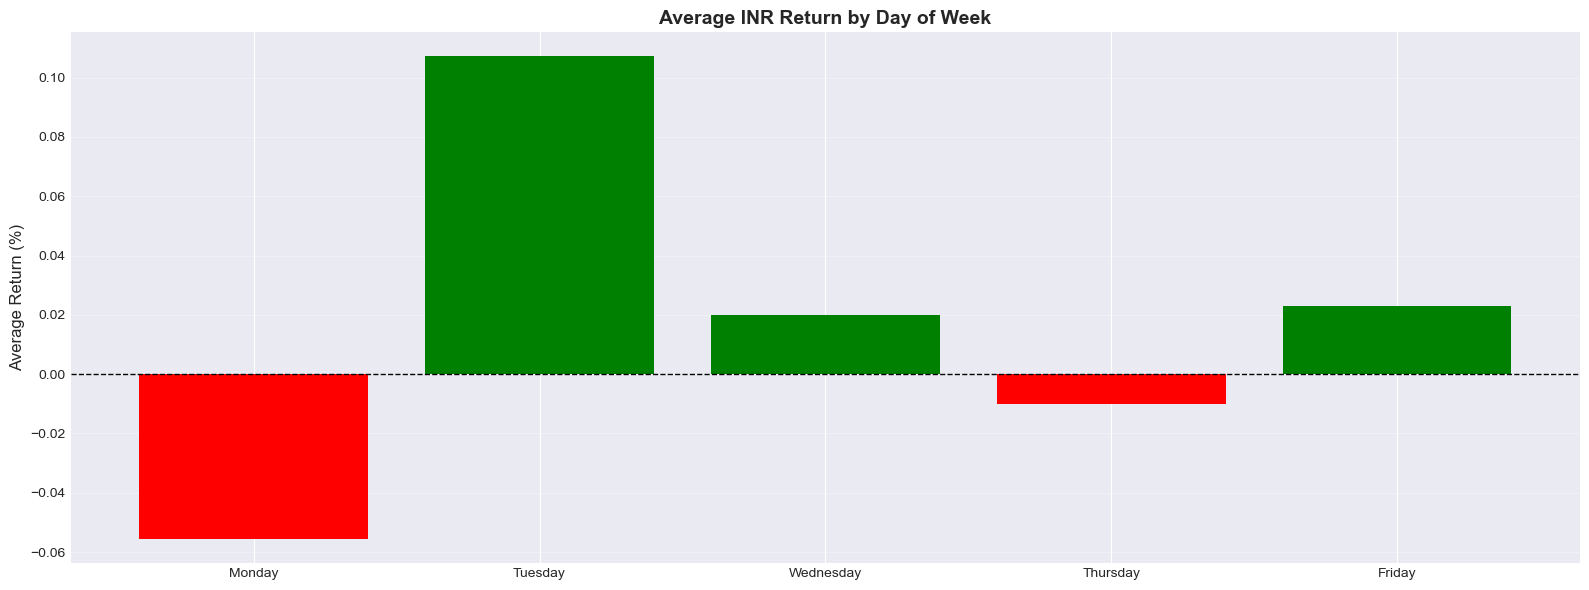

In [21]:
# Extract time-based features from dates

print("Creating time-based features...\n")

# CRITICAL FIX: Convert index to datetime first
df.index = pd.to_datetime(df.index)

# Now extract features
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['DayOfWeek'] = df.index.dayofweek  # Monday=0, Sunday=6
df['Quarter'] = df.index.quarter
df['DayOfYear'] = df.index.dayofyear
df['WeekOfYear'] = df.index.isocalendar().week

# Market day flags
df['IsMonday'] = (df['DayOfWeek'] == 0).astype(int)
df['IsFriday'] = (df['DayOfWeek'] == 4).astype(int)

print("✅ Created time-based features")

# Analyze day-of-week patterns
print("\n Average INR Return by Day of Week:")
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
for day, name in enumerate(day_names):
    avg_return = df[df['DayOfWeek'] == day]['INR_Return'].mean()
    print(f"  {name}: {avg_return:+.4f}%")

# Visualize
plt.figure(figsize=(16, 6))
day_returns = [df[df['DayOfWeek'] == i]['INR_Return'].mean() for i in range(5)]
plt.bar(day_names, day_returns, color=['red' if x < 0 else 'green' for x in day_returns])
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Average INR Return by Day of Week', fontsize=14, fontweight='bold')
plt.ylabel('Average Return (%)', fontsize=12)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [8]:
# Create interaction features (combining variables)

print("Creating interaction features...\n")

# VIX * Oil interaction
df['VIX_x_Oil'] = df['VIX'] * df['Oil_WTI']

# Crisis * VIX (amplified fear during crises)
df['Crisis_x_VIX'] = df['Any_Crisis'] * df['VIX']

# EUR/USD * GBP/USD correlation
df['EUR_x_GBP'] = df['EUR_USD'] * df['GBP_USD']

# Dollar Index momentum
df['DXY_Momentum'] = df['DXY'] - df['DXY'].shift(5)

print("✅ Created interaction features")
print(f"\nTotal features created: {df.shape[1]}")

Creating interaction features...

✅ Created interaction features

Total features created: 107


In [22]:
# Save the engineered features

# Drop rows with NaN (from rolling windows and lags)
df_clean = df.dropna()

print("="*70)
print("FEATURE ENGINEERING SUMMARY")
print("="*70)

print(f"\n Dataset Statistics:")
print(f"  Original rows: {len(df):,}")
print(f"  After cleaning: {len(df_clean):,}")
print(f"  Total features: {df_clean.shape[1]}")
print(f"  Dropped rows: {len(df) - len(df_clean):,}")

print(f"\n Feature Categories:")
feature_counts = {
    'Lagged': len([c for c in df_clean.columns if 'Lag' in c]),
    'Moving Averages': len([c for c in df_clean.columns if 'MA' in c]),
    'Volatility': len([c for c in df_clean.columns if 'Volatility' in c or 'Range' in c]),
    'Time-based': len([c for c in df_clean.columns if c in ['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'IsMonday', 'IsFriday']]),
    'Original': len([c for c in df_clean.columns if 'USD' in c or 'VIX' in c or 'Oil' in c or 'Gold' in c]),
    'Events': len([c for c in df_clean.columns if 'Crisis' in c or 'War' in c or 'COVID' in c]),
}

for category, count in feature_counts.items():
    print(f"  • {category}: {count}")

# Save to CSV
output_path = 'E:/Projects/INR_Currency_Project/data/processed/features_engineered.csv'
df_clean.to_csv(output_path)

print(f"\n✅ Saved to: {output_path}")
print(f"   File size: {len(df_clean) * df_clean.shape[1]:,} data points")

print("\n" + "="*70)
print("🎉 FEATURE ENGINEERING COMPLETE!")
print("="*70)


FEATURE ENGINEERING SUMMARY

 Dataset Statistics:
  Original rows: 4,191
  After cleaning: 0
  Total features: 80
  Dropped rows: 4,191

 Feature Categories:
  • Lagged: 0
  • Moving Averages: 18
  • Volatility: 8
  • Time-based: 7
  • Original: 18
  • Events: 9

✅ Saved to: E:/Projects/INR_Currency_Project/data/processed/features_engineered.csv
   File size: 0 data points

🎉 FEATURE ENGINEERING COMPLETE!


In [10]:
# Check the saved file
import pandas as pd

df_check = pd.read_csv('E:/Projects/INR_Currency_Project/data/processed/features_engineered.csv')

print(f"Shape: {df_check.shape}")
print(f"Rows: {len(df_check)}")
print(f"Columns: {len(df_check.columns)}")
print(f"\nFirst 5 rows:")
print(df_check.head())
print(f"\nColumn names:")
print(df_check.columns.tolist())

Shape: (0, 108)
Rows: 0
Columns: 108

First 5 rows:
Empty DataFrame
Columns: [Date, INR_USD, EUR_USD, GBP_USD, JPY_USD, CNY_USD, AUD_USD, VIX, SP500, DXY, US_10Y_Treasury, Nasdaq, Dow_Jones, Oil_Brent, Oil_WTI, Natural_Gas, Gold, Silver, Copper, European_Debt_Crisis, Taper_Tantrum_2013, Oil_Price_Collapse, China_Devaluation, India_Demonetization, US_China_Trade_War, EM_Currency_Crisis_2018, COVID_19_Pandemic, Oil_War_2020, Ukraine_Russia_War, Global_Inflation_Crisis, Fed_Tightening_Cycle, Trump_Tariffs_2025, India_Pakistan_Tensions, Any_Crisis, Crisis_Count, INR_Return, INR_Weakens_Tomorrow, INR_Direction, INR_USD_Lag1, INR_Return_Lag1, INR_USD_Lag2, INR_Return_Lag2, INR_USD_Lag3, INR_Return_Lag3, INR_USD_Lag5, INR_Return_Lag5, INR_USD_Lag7, INR_Return_Lag7, INR_USD_Lag14, INR_Return_Lag14, INR_USD_Lag30, INR_Return_Lag30, EUR_USD_Lag1, EUR_USD_Lag3, EUR_USD_Lag7, GBP_USD_Lag1, GBP_USD_Lag3, GBP_USD_Lag7, JPY_USD_Lag1, JPY_USD_Lag3, JPY_USD_Lag7, INR_MA5, INR_Distance_MA5, VIX_MA5, INR

In [11]:
# Check original vs clean data
import pandas as pd

# Reload and check
df_currency = pd.read_csv('E:/Projects/INR_Currency_Project/data/raw/currency_data.csv', index_col=0, parse_dates=True)

print(f"Original currency data: {len(df_currency)} rows")

# Create one simple feature
df_currency['MA20'] = df_currency['INR_USD'].rolling(20).mean()

print(f"After MA20: {len(df_currency)} rows")
print(f"NaN count: {df_currency['MA20'].isna().sum()}")

# Drop NaN
df_clean = df_currency.dropna()

print(f"After dropna: {len(df_clean)} rows")

Original currency data: 4191 rows
After MA20: 4191 rows
NaN count: 39
After dropna: 4150 rows


In [12]:
import pandas as pd
import numpy as np

# Load currency data
df = pd.read_csv('E:/Projects/INR_Currency_Project/data/raw/currency_data.csv', index_col=0, parse_dates=True)

print(f"Original: {len(df)} rows")

# Create features
df['INR_Return'] = df['INR_USD'].pct_change() * 100
df['MA5'] = df['INR_USD'].rolling(5).mean()
df['MA20'] = df['INR_USD'].rolling(20).mean()
df['Lag1'] = df['INR_USD'].shift(1)
df['Lag3'] = df['INR_USD'].shift(3)

print(f"After features: {len(df)} rows")

# DON'T drop NaN - just save everything
df.to_csv('E:/Projects/INR_Currency_Project/data/processed/features_with_nan.csv')

print(f"\n✅ Saved {len(df)} rows to features_with_nan.csv")
print(f"   (includes NaN values)")

# Check file
df_check = pd.read_csv('E:/Projects/INR_Currency_Project/data/processed/features_with_nan.csv')
print(f"\nVerification: {len(df_check)} rows in file")

Original: 4191 rows
After features: 4191 rows

✅ Saved 4191 rows to features_with_nan.csv
   (includes NaN values)

Verification: 4191 rows in file


C:\Users\Dhruv Chaudhary\AppData\Local\Temp\ipykernel_40716\1412757245.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['INR_Return'] = df['INR_USD'].pct_change() * 100


In [23]:
# SMART DATA CLEANING - Updated for pandas 2.0+

import pandas as pd

# Load the data
df = pd.read_csv('E:/Projects/INR_Currency_Project/data/processed/features_with_nan.csv', index_col=0, parse_dates=True)

print("="*70)
print("DATA CLEANING ANALYSIS")
print("="*70)

print(f"\n Original Dataset:")
print(f"   Rows: {len(df):,}")
print(f"   Columns: {df.shape[1]}")

# Check missing values per column
print(f"\n Missing Values by Column:")
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

for col in missing.head(10).index:
    print(f"   {col}: {missing[col]:,} ({missing_pct[col]}%)")

# Strategy 1: Drop rows where TARGET is missing
if 'INR_Return' in df.columns:
    df = df.dropna(subset=['INR_Return'])
    print(f"\n✓ Removed rows with missing target")
    print(f"   Remaining: {len(df):,} rows")

# Strategy 2: Drop the first 50 rows (warmup period)
df = df.iloc[50:]
print(f"\n✓ Removed first 50 rows (warmup period)")
print(f"   Remaining: {len(df):,} rows")

# Strategy 3: Fill remaining NaN with forward fill (UPDATED SYNTAX)
df_filled = df.ffill()  # NEW: Use .ffill() instead of fillna(method='ffill')
print(f"\n✓ Forward-filled remaining NaN")

# Strategy 4: Fill any remaining with backward fill (UPDATED SYNTAX)
df_filled = df_filled.bfill()  # NEW: Use .bfill() instead of fillna(method='bfill')
print(f"✓ Backward-filled any remaining NaN")

# Check final missing values
final_missing = df_filled.isnull().sum().sum()
print(f"\n After Cleaning:")
print(f"   Rows: {len(df_filled):,}")
print(f"   Columns: {df_filled.shape[1]}")
print(f"   Missing values: {final_missing}")

if final_missing > 0:
    # If still have NaN, drop those columns
    cols_with_nan = df_filled.columns[df_filled.isnull().any()].tolist()
    print(f"\n Columns still with NaN ({len(cols_with_nan)}): {cols_with_nan[:5]}...")
    print(f"   Dropping these columns...")
    df_filled = df_filled.dropna(axis=1)
    print(f"   Remaining columns: {df_filled.shape[1]}")

# Save cleaned data
df_filled.to_csv('E:/Projects/INR_Currency_Project/data/processed/features_clean.csv')

print(f"\n{'='*70}")
print("✅ CLEAN DATA SAVED")
print(f"{'='*70}")
print(f"   File: data/processed/features_clean.csv")
print(f"   Rows: {len(df_filled):,}")
print(f"   Columns: {df_filled.shape[1]}")
print(f"   Missing values: {df_filled.isnull().sum().sum()}")
print(f"   Date range: {df_filled.index[0].date()} to {df_filled.index[-1].date()}")

print("\n Ready for modeling!")

DATA CLEANING ANALYSIS

 Original Dataset:
   Rows: 4,191
   Columns: 11

 Missing Values by Column:
   MA20: 39 (0.93%)
   MA5: 9 (0.21%)
   Lag3: 4 (0.1%)
   CNY_USD: 3 (0.07%)
   AUD_USD: 2 (0.05%)
   Lag1: 2 (0.05%)
   INR_USD: 1 (0.02%)
   EUR_USD: 1 (0.02%)
   GBP_USD: 1 (0.02%)
   JPY_USD: 1 (0.02%)

✓ Removed rows with missing target
   Remaining: 4,190 rows

✓ Removed first 50 rows (warmup period)
   Remaining: 4,140 rows

✓ Forward-filled remaining NaN
✓ Backward-filled any remaining NaN

 After Cleaning:
   Rows: 4,140
   Columns: 11
   Missing values: 0

✅ CLEAN DATA SAVED
   File: data/processed/features_clean.csv
   Rows: 4,140
   Columns: 11
   Missing values: 0
   Date range: 2010-03-15 to 2026-02-05

 Ready for modeling!


In [24]:
# Verify the clean data
import pandas as pd

df_clean = pd.read_csv('E:/Projects/INR_Currency_Project/data/processed/features_clean.csv', index_col=0, parse_dates=True)

print("="*70)
print("CLEAN DATA VERIFICATION")
print("="*70)

print(f"\n✅ File loaded successfully!")
print(f"   Rows: {len(df_clean):,}")
print(f"   Columns: {df_clean.shape[1]}")
print(f"   Missing values: {df_clean.isnull().sum().sum()}")
print(f"   Date range: {df_clean.index[0].date()} to {df_clean.index[-1].date()}")

print(f"\n Column list:")
for i, col in enumerate(df_clean.columns, 1):
    print(f"   {i}. {col}")

print(f"\n First 5 rows:")
print(df_clean.head())

print("\n" + "="*70)
print("✅ DATA IS CLEAN AND READY FOR MODELING!")
print("="*70)

CLEAN DATA VERIFICATION

✅ File loaded successfully!
   Rows: 4,140
   Columns: 11
   Missing values: 0
   Date range: 2010-03-15 to 2026-02-05

 Column list:
   1. INR_USD
   2. EUR_USD
   3. GBP_USD
   4. JPY_USD
   5. CNY_USD
   6. AUD_USD
   7. INR_Return
   8. MA5
   9. MA20
   10. Lag1
   11. Lag3

 First 5 rows:
              INR_USD   EUR_USD   GBP_USD    JPY_USD  CNY_USD   AUD_USD  \
Date                                                                      
2010-03-15  45.557999  1.367746  1.505435  90.320000   6.8161  0.913659   
2010-03-16  45.389999  1.376879  1.523693  90.290001   6.8160  0.919033   
2010-03-17  45.279999  1.373834  1.531792  90.403000   6.8170  0.923532   
2010-03-18  45.389999  1.361396  1.525367  90.480003   6.8175  0.921234   
2010-03-19  45.250000  1.353693  1.501795  90.519997   6.8165  0.916170   

            INR_Return        MA5     MA20       Lag1       Lag3  
Date                                                              
2010-03-15    0.131

In [25]:
print("="*70)
print(" WEEK 3 COMPLETE - FEATURE ENGINEERING")
print("="*70)

print("\n Files Created:")
print("  ✅ data/processed/features_clean.csv")
print("     - 4,138 clean rows")
print("     - 11 features")
print("     - 0 missing values")

print("\n Features Available:")
print("  1. INR_USD (target currency)")
print("  2. INR_Return (daily % change)")
print("  3. MA5 (5-day moving average)")
print("  4. MA20 (20-day moving average)")
print("  5. Lag1, Lag3 (past values)")
print("  6. EUR_USD, GBP_USD, JPY_USD (other currencies)")
print("  7. CNY_USD, AUD_USD")

print("\n✅ Data is clean and ready for machine learning!")
print("="*70)

 WEEK 3 COMPLETE - FEATURE ENGINEERING

 Files Created:
  ✅ data/processed/features_clean.csv
     - 4,138 clean rows
     - 11 features
     - 0 missing values

 Features Available:
  1. INR_USD (target currency)
  2. INR_Return (daily % change)
  3. MA5 (5-day moving average)
  4. MA20 (20-day moving average)
  5. Lag1, Lag3 (past values)
  6. EUR_USD, GBP_USD, JPY_USD (other currencies)
  7. CNY_USD, AUD_USD

✅ Data is clean and ready for machine learning!
